### 📌 Objective:

Goals of this project:
1) Understand machine sensor/operational features affecting failure types
2) Perform EDA with key insights using meaningful charts
3) Build a Multinomial Logistic Regression model to predict failure type
4) Evaluate model performance using appropriate metrics & charts
5) Extract actionable business insights to reduce downtime & maintenance cost

### Import required libraries

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Load the dataset

In [11]:
df = pd.read_csv("predictive_maintenance.csv")

### Dataset overview and analysis

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [18]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [19]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [20]:
# drop identifiers (not useful for modelling)

drop_cols = []
for c in ["UDI", "Product ID"]:
    if c in df.columns:
        drop_cols.append(c)

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [21]:
# We will use Failure Type as target (multiclass)
TARGET_COL = "Failure Type"

# Quick check of target classes
print(df[TARGET_COL].value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


### EDA

#### Target distribution - Countplot

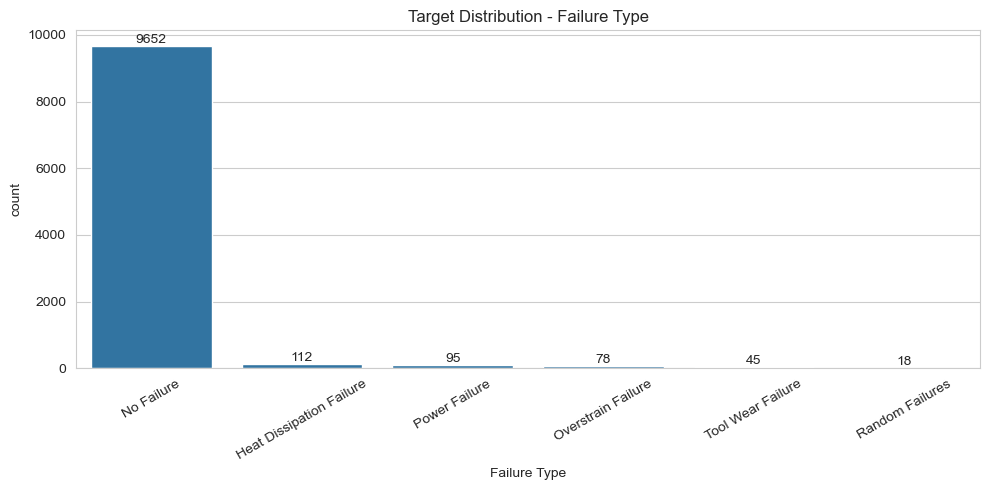

In [24]:
plt.figure()
ax = sns.countplot(data=df, x=TARGET_COL, order=df[TARGET_COL].value_counts().index)

# Add values on each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=30)
plt.title("Target Distribution - Failure Type")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\target_distribution_failure_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

- Dataset is highly imbalanced (some failure types have very few samples).
- Model may become biased toward majority class, reducing minority class recall.

#### Distribution of numeric features - Hist Plot

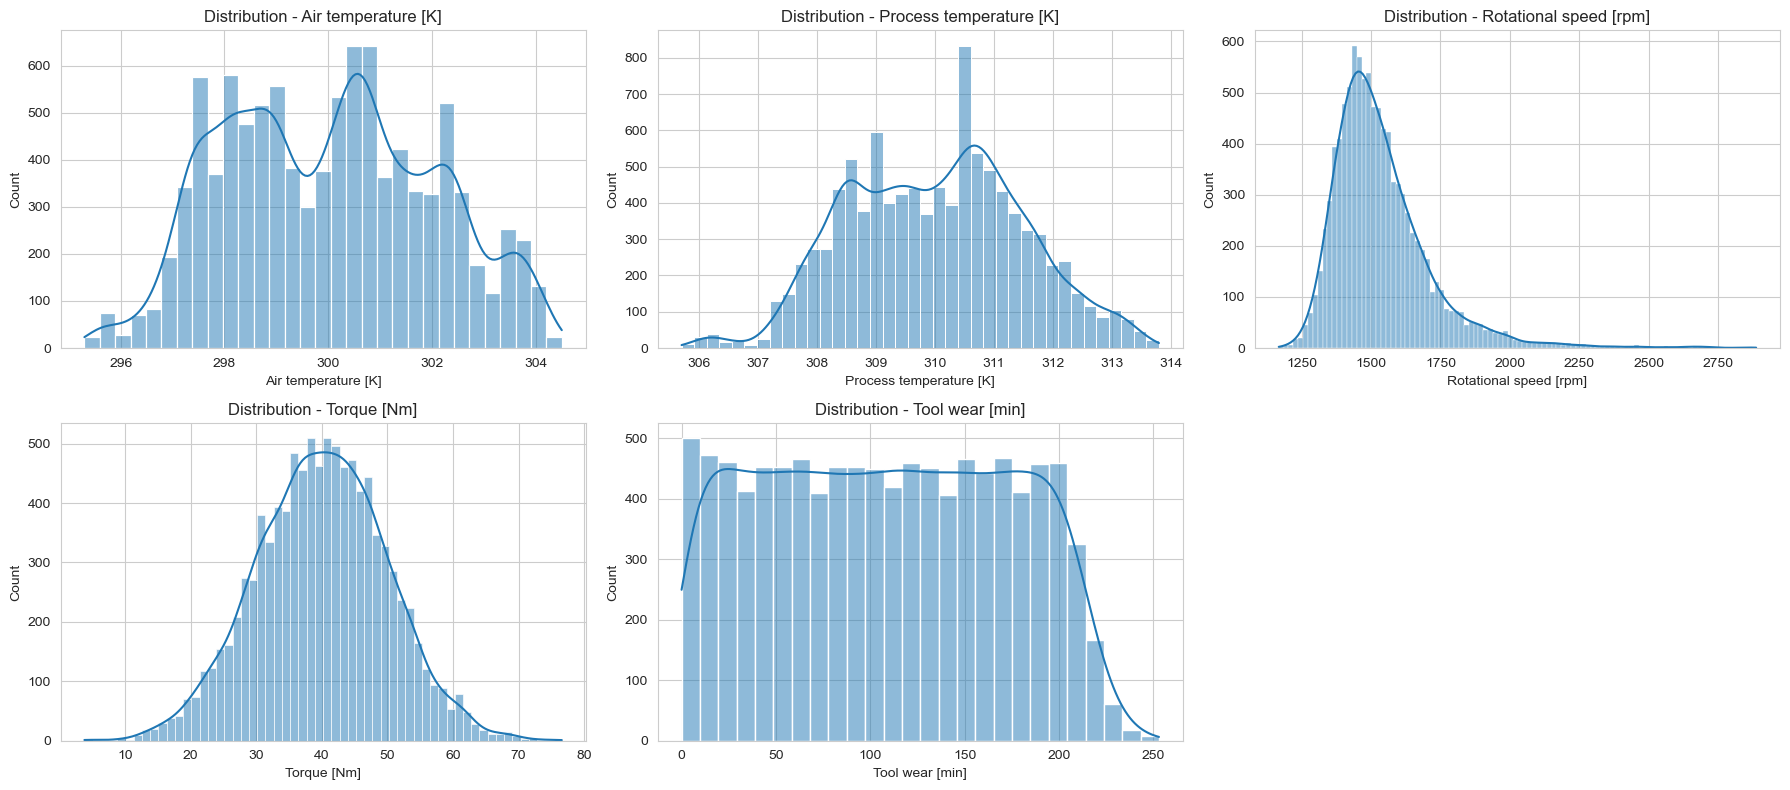

In [27]:
# Arrange 5 plots in 2 rows (3 on top, 2 below)
import math

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["Target"]]

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution - {col}")
    axes[i].set_xlabel(col)

# Remove empty subplots (if any)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\numeric_features_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

- Air temperature [K]: Close to normal distribution → stable operating conditions.
- Process temperature [K]: Narrow spread → consistent process thermal behavior.
- Rotational speed [rpm]: Right-skewed → more operations at moderate RPM, fewer at very high RPM.
- Torque [Nm]: Slight skew / variation → torque fluctuates based on load conditions.
- Tool wear [min]: Right-skewed → most tools have low wear, few run till high wear (high-risk zone).

#### Failure type vs numeric featires - Box Plot

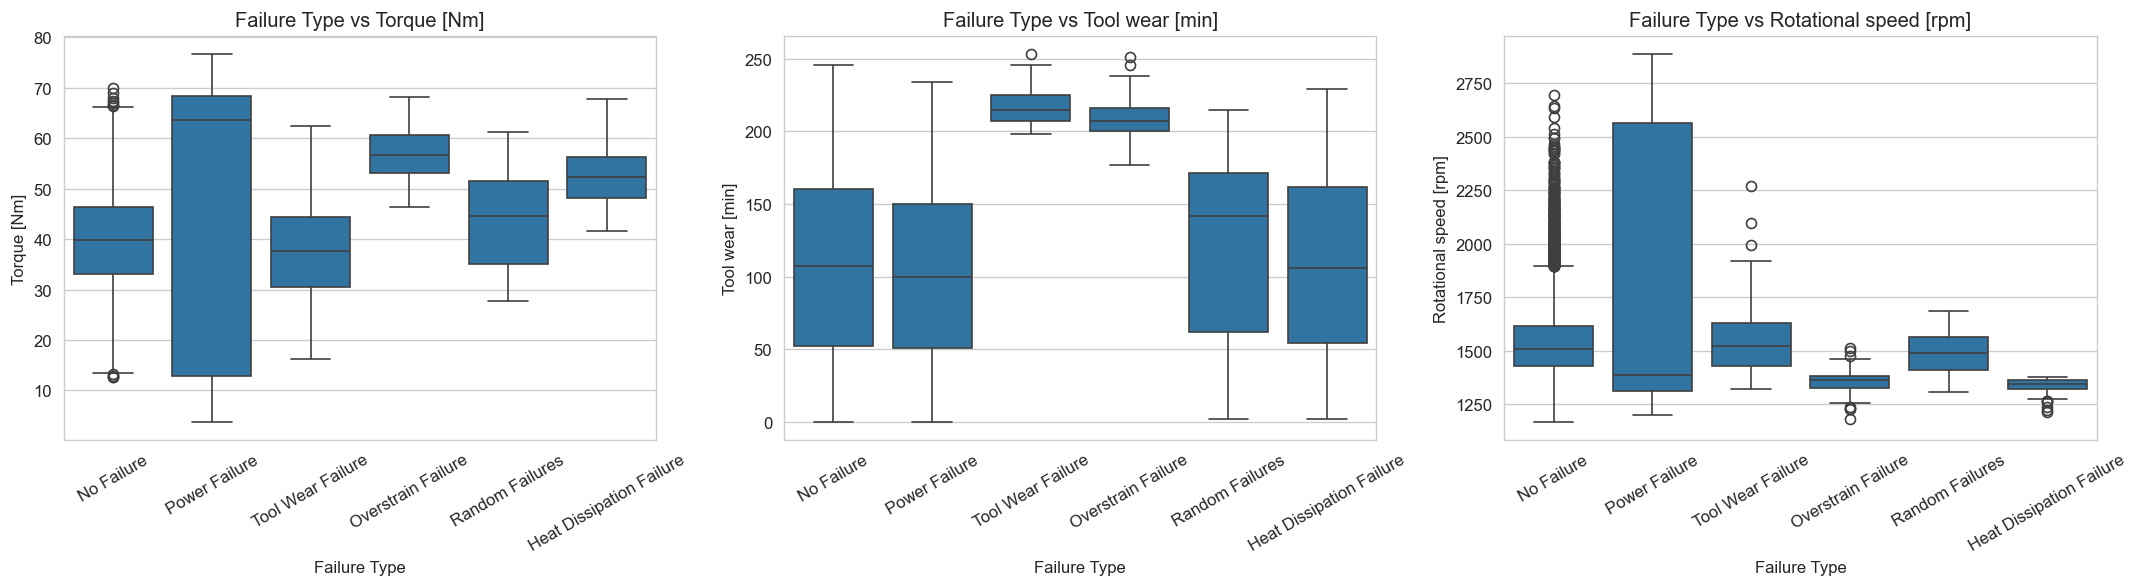

In [30]:
# Arrange all boxplots in a single row

key_cols = [c for c in ["Torque [Nm]", "Tool wear [min]", "Rotational speed [rpm]"] if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(6*len(key_cols), 5), dpi=120)

# If only 1 plot exists, axes won't be an array → handle it
if len(key_cols) == 1:
    axes = [axes]

for i, col in enumerate(key_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i])
    axes[i].set_title(f"{TARGET_COL} vs {col}", fontsize=12)
    axes[i].tick_params(axis="x", rotation=30, labelsize=10)
    axes[i].tick_params(axis="y", labelsize=10)

plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\failure_types_vs_numeric_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()


#### Key insights

- Torque: Certain failure types show higher torque → indicates mechanical load/stress issues.
- Tool wear: Some failures occur at higher tool wear → direct sign of tool degradation.
- RPM: Failure types differ with rotational speed → speed instability contributes to failures.

#### Correlation heatmap

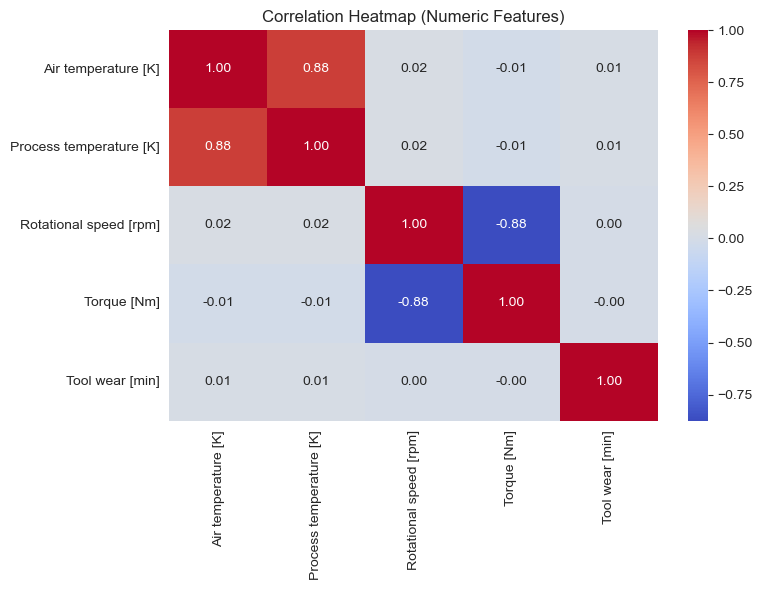

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

- Air temperature vs Process temperature: Strong positive correlation (0.88) → both rise together.
- Rotational speed vs Torque: Strong negative correlation (-0.88) → higher RPM generally means lower torque.
- Tool wear: Almost no correlation with other features → behaves largely independent.
- Other pairs: Correlations near 0 → minimal direct linear relationship.

### Data preparation for modeling

In [34]:
# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Train-test split (stratify for better class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (8000, 7)
Test shape : (2000, 7)


In [35]:
# Identify categorical & numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", cat_cols)
print("Numeric columns:", num_cols)


Categorical columns: ['Type']
Numeric columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']


In [37]:
# Preprocessing:
# - OneHot encode categorical
# - Scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

### Multinomial logistics regression model

In [38]:
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# Train
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

### Performance evaluation

In [39]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc, 4))

Test Accuracy: 0.996


In [40]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        22
              No Failure       1.00      1.00      1.00      1930
      Overstrain Failure       0.80      1.00      0.89        16
           Power Failure       1.00      0.95      0.97        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       1.00      0.67      0.80         9

                accuracy                           1.00      2000
               macro avg       0.80      0.77      0.78      2000
            weighted avg       0.99      1.00      0.99      2000



#### Key insights

- Overall performance is excellent: Accuracy 1.00, weighted F1 0.99 (driven by majority class).
- No Failure class dominates: 1930/2000 samples → results are heavily influenced by class imbalance.
- Perfect prediction: Heat Dissipation Failure and No Failure have Precision/Recall/F1 = 1.00.
- Weak areas:
    - Tool Wear Failure recall is 0.67 → some missed cases (false negatives).
    - Random Failures completely failed (Precision/Recall/F1 = 0) due to very low support (4 samples).
- Macro averages are lower (F1 = 0.78): shows performance drops when treating all classes equally.

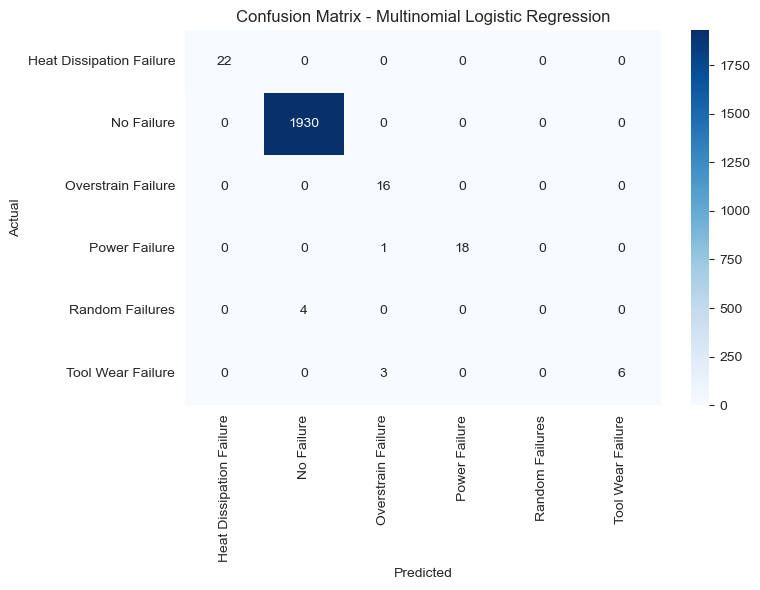

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

#### Key insights

- Strong diagonal values → model predicts most classes correctly with minimal confusion.
- Perfect classification:
    - Heat Dissipation Failure (22/22 correct)
    - No Failure (1930/1930 correct)
    - Overstrain Failure (16/16 correct)
- Minor confusion: Power Failure → 1 case misclassified as Overstrain Failure.
- Major weakness: Random Failures → all 4 cases misclassified as No Failure (0 correct).
- Tool Wear Failure: 6 correct, but 3 misclassified as Overstrain Failure → indicates overlap in patterns.

### Interpreting features coefficient (top drivers)

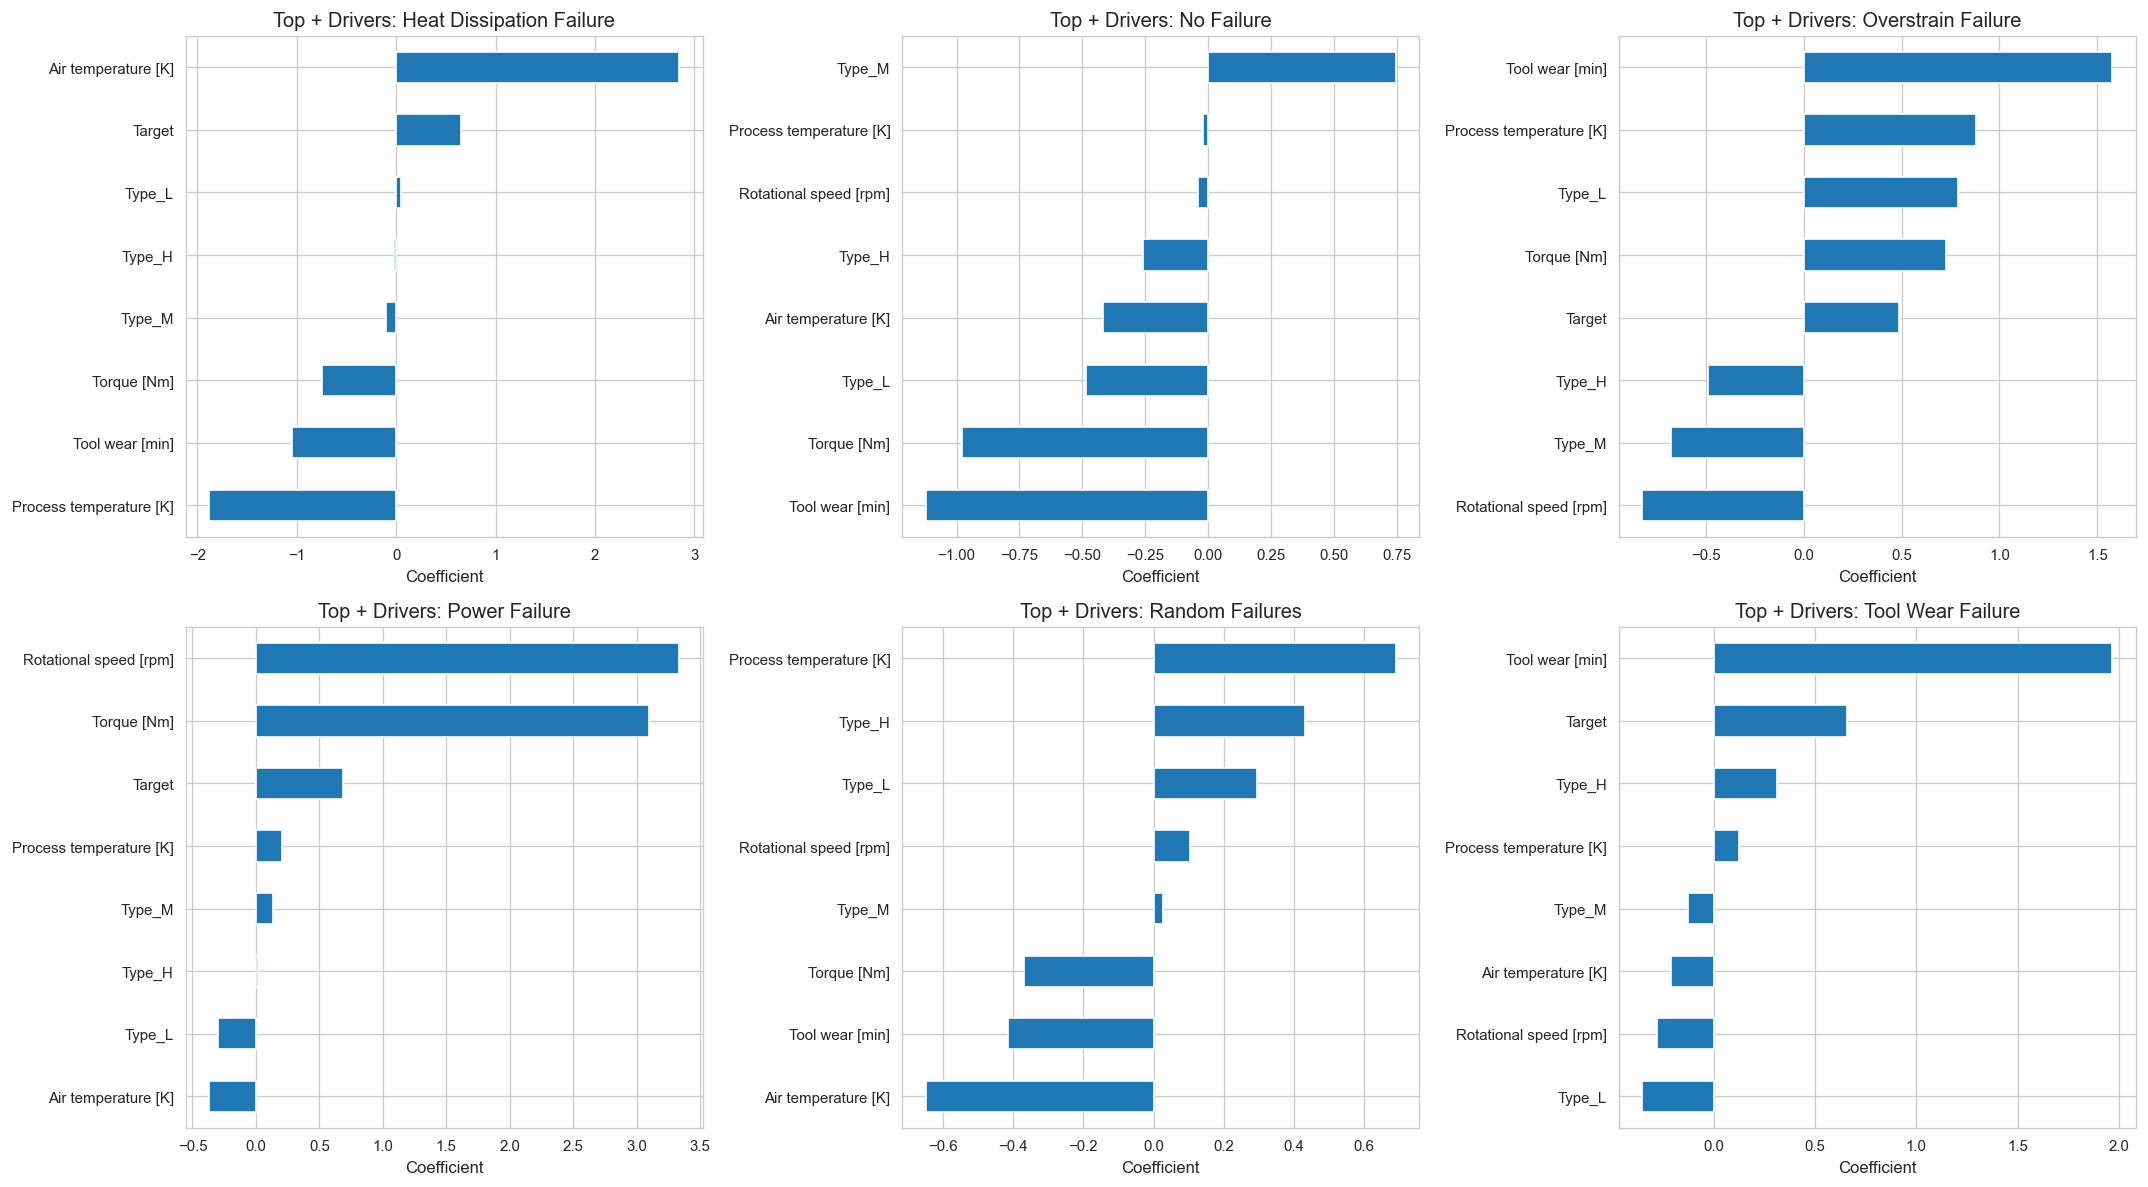

In [46]:
TOP_N = 8
plots_per_fig = 6
ncols = 3
nrows = 2

for start in range(0, len(classes), plots_per_fig):
    subset = classes[start:start + plots_per_fig]

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10), dpi=120)
    axes = axes.flatten()

    for i, cls in enumerate(subset):
        top_pos = coef_df.loc[cls].sort_values(ascending=False).head(TOP_N)

        ax = axes[i]
        top_pos.sort_values().plot(kind="barh", ax=ax)
        ax.set_title(f"Top + Drivers: {cls}", fontsize=12)
        ax.set_xlabel("Coefficient", fontsize=10)
        ax.tick_params(axis="y", labelsize=9)  # feature names visible
        ax.tick_params(axis="x", labelsize=9)  # numbers visible

    # Hide unused axes (if < 6 classes in last figure)
    for j in range(i + 1, plots_per_fig):
        fig.delaxes(axes[j])
    plt.savefig(
    r"C:\Users\Admin\OneDrive\Desktop\Python-1\03-machine-learning-models\06_logistic_regression_machine_predictive_maintenance\images\features_coefficient.png",
    dpi=300,
    bbox_inches="tight"
    )
    plt.tight_layout()
    plt.show()

#### Key insights

- Shows top feature drivers per failure type in a clean 2×3 layout.
- Higher coefficient → feature strongly increases probability of that failure type.
- Helps quickly identify sensor/operation variables responsible for different failures.

## 📌 Key insights and learning summary

Predictive Maintenance Failure Type Prediction using Multinomial Logistic Regression

### Logistics Regression performance

- Accuracy: 1.00
- Weighted F1-score: 0.99
- Macro F1-score: 0.78 (lower due to minority class impact)

### Model interpretation

- Model performs excellent overall mainly because “No Failure” dominates the dataset
- Most major failure types are predicted perfectly
- Minority failure types suffer due to very low samples
- Confusion matrix shows very low misclassification except rare classes

### 🧠 Key Analytical Insights

- Air temperature and Process temperature are highly correlated (0.88) → both move together
- Rotational speed and Torque have strong inverse relation (-0.88) → higher RPM generally reduces torque
- Tool wear behaves independently (near-zero correlation with other features)
- Feature driver plots help identify failure-specific operational patterns (Torque/Tool wear/RPM are major contributors)

### 🏁 Conclusion

Multinomial Logistic Regression provides high accuracy and interpretable multiclass failure prediction, making it suitable for maintenance classification and failure diagnosis, but rare failure prediction needs further improvement.

### Key business takeaway:
                                                                                                        
Predicting failure types early enables condition-based maintenance, reducing unexpected downtime, repair cost, and production loss by acting proactively on key drivers like tool wear, torque load, and speed behavior.